In [1]:
# CELL 1: Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['figure.dpi'] = 120
import warnings
warnings.filterwarnings('ignore')


Load Data

In [2]:
# CELL 2: Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
# CELL 3: Load PaySim from Drive

df = pd.read_csv('/content/drive/MyDrive/Project/PS_20174392719_1491204439457_log.csv')

print(f"Shape: {df.shape}")

print('rows:', len(df))
print('columns:', list(df.columns))
df.head(3)

Shape: (6362620, 11)
rows: 6362620
columns: ['step', 'type', 'amount', 'nameOrig', 'oldbalanceOrg', 'newbalanceOrig', 'nameDest', 'oldbalanceDest', 'newbalanceDest', 'isFraud', 'isFlaggedFraud']


,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,1,PAYMENT,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0,0
1,1,PAYMENT,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0,0
2,1,TRANSFER,181.00,C1305486145,181.0,0.00,C553264065,0.0,0.0,1,0


Exploration

In [4]:
# fraud rate overall
print('fraud rate:', round(df['isFraud'].mean() * 100, 4), '%')
print('fraud count:', df['isFraud'].sum())
print('total:', len(df))

print()

# breakdown by transaction type
fraud_by_type = df.groupby('type')['isFraud'].agg(['sum', 'mean', 'count'])
fraud_by_type.columns = ['fraud_count', 'fraud_rate', 'total']
print(fraud_by_type)

fraud rate: 0.1291 %
fraud count: 8213
total: 6362620

          fraud_count  fraud_rate    total
type                                      
CASH_IN             0    0.000000  1399284
CASH_OUT         4116    0.001840  2237500
DEBIT               0    0.000000    41432
PAYMENT             0    0.000000  2151495
TRANSFER         4097    0.007688   532909


Fraud only appears in `CASH_OUT` and `TRANSFER` types.
Everything else has zero fraud. So I can safely drop `PAYMENT`, `CASH_IN`, and `DEBIT` to reduce the dataset size.

In [5]:
# keeping only the two types that actually have fraud
df_filtered = df[df['type'].isin(['CASH_OUT', 'TRANSFER'])].copy()
df_filtered = df_filtered.sort_values(['nameOrig', 'step']).reset_index(drop=True)

print('before:', len(df), 'rows')
print('after:', len(df_filtered), 'rows')
print('fraud rate after filter:', round(df_filtered['isFraud'].mean() * 100, 4), '%')
print('fraud transactions kept:', df_filtered['isFraud'].sum())

before: 6362620 rows
after: 2770409 rows
fraud rate after filter: 0.2965 %
fraud transactions kept: 8213


Exploratory Analysis

In [6]:
# CELL 6: Basic statistics

# how different are the amounts?
print('amount stats by fraud label:')
print(df_filtered.groupby('isFraud')['amount'].describe().round(2))

# does fraud drain the account?
df_filtered['balance_change_orig'] = df_filtered['newbalanceOrig'] - df_filtered['oldbalanceOrg']
print('\navg balance change for fraud:', round(df_filtered[df_filtered['isFraud']==1]['balance_change_orig'].mean(), 2))
print('avg balance change for normal:', round(df_filtered[df_filtered['isFraud']==0]['balance_change_orig'].mean(), 2))

amount stats by fraud label:
             count       mean         std   min        25%        50%  \
isFraud                                                                 
0        2762196.0   314115.5   877144.15  0.01   82908.23  171034.46   
1           8213.0  1467967.3  2404252.95  0.00  127091.33  441423.44   

                75%          max  
isFraud                           
0         305994.18  92445516.64  
1        1517771.48  10000000.00  

avg balance change for fraud: -1457274.97
avg balance change for normal: -27311.99


Fraud transactions are on average about 4.7x larger than normal, and they drain the sender's balance almost completely. The balance change for fraud is strongly negative.

Now plotting a few things visually to get a better sense of the patterns.

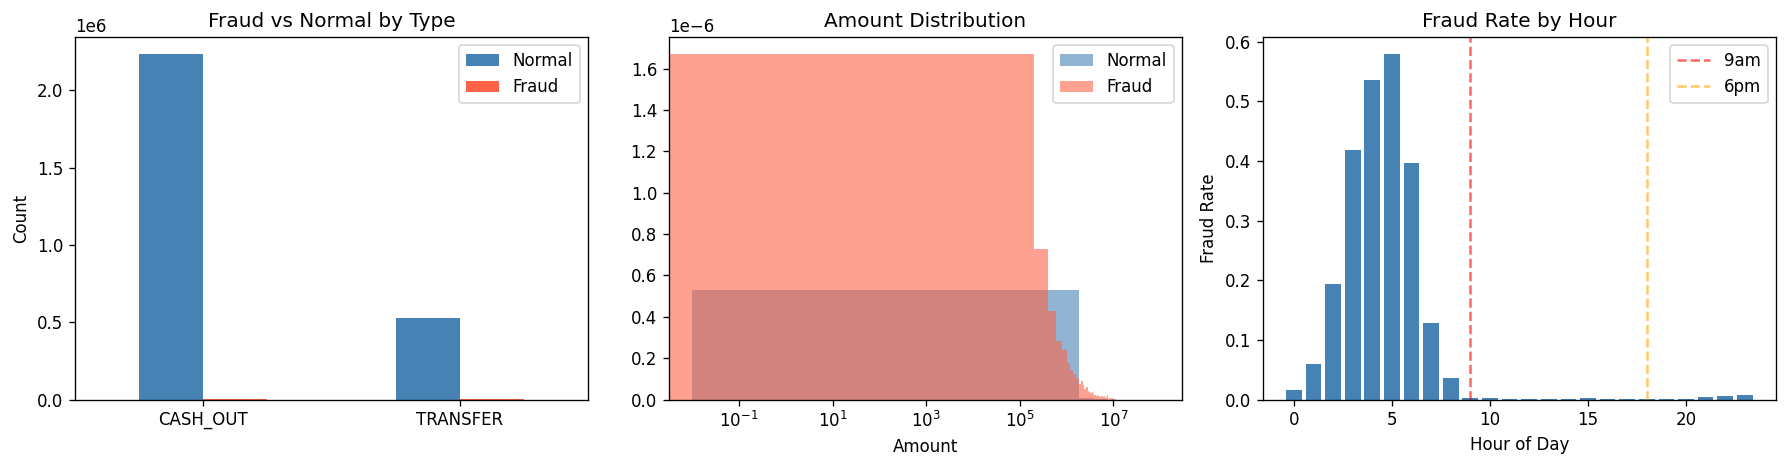

In [7]:
# CELL 7: Visualise fraud distribution

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# plot 1 - fraud by type
type_counts = df_filtered.groupby(['type', 'isFraud']).size().unstack(fill_value=0)
type_counts.plot(kind='bar', ax=axes[0], color=['steelblue', 'tomato'])
axes[0].set_title('Fraud vs Normal by Type')
axes[0].set_xlabel('')
axes[0].set_ylabel('Count')
axes[0].legend(['Normal', 'Fraud'])
axes[0].tick_params(axis='x', rotation=0)

# plot 2 - amount distribution
axes[1].hist(df_filtered[df_filtered['isFraud']==0]['amount'],
             bins=50, alpha=0.6, color='steelblue', label='Normal', density=True)
axes[1].hist(df_filtered[df_filtered['isFraud']==1]['amount'],
             bins=50, alpha=0.6, color='tomato', label='Fraud', density=True)
axes[1].set_title('Amount Distribution')
axes[1].set_xlabel('Amount')
axes[1].set_xscale('log')
axes[1].legend()

# plot 3 - fraud by hour
df_filtered['hour'] = df_filtered['step'] % 24
hour_fraud = df_filtered.groupby('hour')['isFraud'].mean()
axes[2].bar(hour_fraud.index, hour_fraud.values, color='steelblue')
axes[2].axvline(x=9, color='red', linestyle='--', alpha=0.6, label='9am')
axes[2].axvline(x=18, color='orange', linestyle='--', alpha=0.6, label='6pm')
axes[2].set_title('Fraud Rate by Hour')
axes[2].set_xlabel('Hour of Day')
axes[2].set_ylabel('Fraud Rate')
axes[2].legend()

plt.tight_layout()
plt.savefig('eda_plots.png', bbox_inches='tight')
plt.show()


The third plot is interesting as the fraud is noticeably higher outside normal banking hours (before 9am and after 6pm). This confirms that the `outside_hours` feature I planned makes sense.

Feature Engineering

In [8]:
# CELL 8: Add Irish CBI Feature 1 - Amount Ratio
# The CBI reports the average Irish P2P mobile transfer is around €65. Instead of using the raw amount, I divide by this baseline.
# A fraud transaction sending €10,000 gives a ratio of ~154 which is obviously suspicious. A legitimate €50 transfer gives a ratio of ~0.77 which is normal.

CBI_P2P_AVG = 65.0

df_filtered['amount_ratio'] = df_filtered['amount'] / CBI_P2P_AVG

print('amount_ratio - fraud vs normal:')
print('fraud mean:', round(df_filtered[df_filtered['isFraud']==1]['amount_ratio'].mean(), 1), 'x the CBI average')
print('normal mean:', round(df_filtered[df_filtered['isFraud']==0]['amount_ratio'].mean(), 1), 'x the CBI average')
print('\nfull stats:')
print(df_filtered['amount_ratio'].describe().round(2))


amount_ratio - fraud vs normal:
fraud mean: 22584.1 x the CBI average
normal mean: 4832.5 x the CBI average

full stats:
count    2770409.00
mean        4885.17
std        13658.30
min            0.00
25%         1276.52
50%         2634.78
75%         4719.86
max      1422238.72
Name: amount_ratio, dtype: float64


In [9]:
# CELL 9: Add Irish CBI Feature 2 - Time of Day Anomaly
# CBI seasonal data shows Irish banking activity 09:00-18:00 weekdays
# From the hour plot above, fraud is clearly more common outside normal Irish banking hours. CBI seasonal data backs this up. Flagging anything before 9am or after 6pm as a binary 1/0.

df_filtered['outside_hours'] = (
    (df_filtered['hour'] < 9) | (df_filtered['hour'] > 18)
).astype(int)

fraud_inside = df_filtered[df_filtered['outside_hours']==0]['isFraud'].mean() * 100
fraud_outside = df_filtered[df_filtered['outside_hours']==1]['isFraud'].mean() * 100

print(f'fraud rate inside banking hours (9am-6pm): {fraud_inside:.4f}%')
print(f'fraud rate outside banking hours: {fraud_outside:.4f}%')
print(f'fraud is {round(fraud_outside/fraud_inside, 1)}x more likely outside hours')

fraud rate inside banking hours (9am-6pm): 0.1730%
fraud rate outside banking hours: 0.6167%
fraud is 3.6x more likely outside hours


I originally tried a velocity feature (counting how many transactions a sender makes per hour) but after running it the correlation was basically zero i.e. almost every sender in PaySim makes only 1 transaction, so there's no variation to learn from. Dropped it.

This replacement checks whether the sender's balance went to zero after the transaction. Looking at the balance change stats earlier, fraud transactions drain accounts almost completely, so this should be a useful signal.

In [10]:
# CELL 10: Add account_emptied feature
# velocity_1h already removed - adding stronger replacement

df_filtered['account_emptied'] = (df_filtered['newbalanceOrig'] == 0).astype(int)

fraud_emptied = df_filtered[df_filtered['account_emptied']==1]['isFraud'].mean() * 100
fraud_not_emptied = df_filtered[df_filtered['account_emptied']==0]['isFraud'].mean() * 100

print(f'accounts that went to zero: {df_filtered["account_emptied"].sum():,}')
print(f'fraud rate when emptied: {fraud_emptied:.4f}%')
print(f'fraud rate when not emptied: {fraud_not_emptied:.4f}%')

accounts that went to zero: 2,496,656
fraud rate when emptied: 0.3226%
fraud rate when not emptied: 0.0584%


CBI data on Irish APP fraud shows money is usually transferred to newly opened accounts (money mule accounts). If a recipient has received fewer than 3 transactions in the dataset, I flag them as high risk. Using `cumcount()` to track how many times each destination account has appeared so far.

In [11]:
# CELL 11: Add Irish CBI Feature 4 - Recipient Risk Score
# New accounts receiving money = potential money mule
# Common pattern in Irish APP fraud (CBI 2024/2025 data)

recipient_counts = df_filtered.groupby('nameDest').cumcount()
df_filtered['recipient_risk_score'] = (recipient_counts < 3).astype(int)

fraud_risky = df_filtered[df_filtered['recipient_risk_score']==1]['isFraud'].mean() * 100
fraud_safe = df_filtered[df_filtered['recipient_risk_score']==0]['isFraud'].mean() * 100

print(f'transactions to high-risk recipients: {df_filtered["recipient_risk_score"].sum():,}')
print(f'fraud rate - high risk recipient: {fraud_risky:.4f}%')
print(f'fraud rate - established recipient: {fraud_safe:.4f}%')
print(f'fraud is {round(fraud_risky/fraud_safe, 1)}x more likely with new recipient')

transactions to high-risk recipients: 1,192,584
fraud rate - high risk recipient: 0.4992%
fraud rate - established recipient: 0.1432%
fraud is 3.5x more likely with new recipient


Confirming the 6 columns going into XGBoost training:
4 engineered features + 2 raw PaySim balance columns which I'm keeping because they had strong correlations in initial checks.

In [12]:
# CELL 12: Confirm all features and define final feature list

FEATURES = [
    'amount_ratio',          # CBI engineered
    'outside_hours',         # CBI engineered
    'account_emptied',       # PaySim pattern
    'recipient_risk_score',  # CBI engineered
    'oldbalanceOrg',         # raw PaySim
    'newbalanceOrig'         # raw PaySim
]
TARGET = 'isFraud'

print('final features:', FEATURES)
print('target:', TARGET)
print('dataset shape:', df_filtered.shape)
print()
print('sample:')
df_filtered[FEATURES + [TARGET]].head(5)

final features: ['amount_ratio', 'outside_hours', 'account_emptied', 'recipient_risk_score', 'oldbalanceOrg', 'newbalanceOrig']
target: isFraud
dataset shape: (2770409, 17)

sample:


,amount_ratio,outside_hours,account_emptied,recipient_risk_score,oldbalanceOrg,newbalanceOrig,isFraud
0,3761.330154,0,1,1,8946.00,0.00,0
1,3249.071385,0,1,1,0.00,0.00,0
2,1444.078923,0,0,1,351422.72,257557.59,0
3,49667.540154,0,1,1,24996.00,0.00,0
4,3586.304462,0,1,1,20623.00,0.00,0


In [13]:
# CELL 13: Correlation of all features with fraud label

print('correlation with isFraud:')
for feat in FEATURES:
    c = df_filtered[feat].corr(df_filtered[TARGET])
    print(f'  {feat}: {c:.4f}')

# oldbalanceOrg at 0.35 is the strongest individual predictor
# the CBI features are lower but should combine well in XGBoost

correlation with isFraud:
  amount_ratio: 0.0707
  outside_hours: 0.0366
  account_emptied: 0.0145
  recipient_risk_score: 0.0324
  oldbalanceOrg: 0.3476
  newbalanceOrig: 0.0636


In [14]:
# CELL 14: Save processed dataset to Google Drive

df_filtered.to_csv(
    '/content/drive/MyDrive/Project/sentinelguard_processed.csv',
    index=False
)
print('saved.')
print('shape:', df_filtered.shape)
print('columns:', list(df_filtered.columns))

saved.
shape: (2770409, 17)
columns: ['step', 'type', 'amount', 'nameOrig', 'oldbalanceOrg', 'newbalanceOrig', 'nameDest', 'oldbalanceDest', 'newbalanceDest', 'isFraud', 'isFlaggedFraud', 'balance_change_orig', 'hour', 'amount_ratio', 'outside_hours', 'account_emptied', 'recipient_risk_score']


Summary
- Loaded PaySim — 6,362,620 rows, 0.1291% fraud rate
- Found fraud only exists in CASH_OUT and TRANSFER types — filtered to 2,770,409 rows
- Confirmed fraud transactions are ~4.7x larger on average
- Fraud is 3.6x more likely outside Irish banking hours
- Fraud is 3.5x more likely when recipient is a new account
- Tried velocity feature — dropped it (near-zero correlation, no sender variation in PaySim)
- Engineered 4 features based on CBI Irish statistics
- Final feature set: 6 columns ready for XGBoost training